<a href="https://colab.research.google.com/github/Ololade117/Inducing-Polysemanticity/blob/main/Crude_Scaling_Normal_vs_Flex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scaling Experiments: Normal vs. Flex Bias

Two sweeps, run for both `normal` and `flex` bias types:

1. **Params sweep**: 10 models, width (`d_model`) increasing from the
   baseline ~3.7M-param size up to ~46M params (12.5x), **training steps held
   fixed** at the baseline value.
2. **Steps sweep**: 10 models, all at the baseline ~3.7M param size,
   **training steps increasing** from the baseline up to 14x that many.

The smallest model in both sweeps is the same ~3.7M-param, baseline-steps
configuration -- it's trained once and used as the first data point in both
comparisons, rather than trained twice.

**Why one config-driven loop instead of 40 hand-written sections**: at this
scale, 40 near-identical copy-pasted cells would be long, error-prone, and
painful to fix if one hyperparameter needed to change everywhere. Instead,
this notebook builds one table describing all 38 unique training runs (2
bias types x 19 unique configs each, sharing the baseline), then trains,
evaluates, and pushes each with one reusable function.

## Read this before running: expected cost

This is a genuinely large amount of compute, not a "run it and it's done in a
few minutes" notebook:

- **Params sweep**: holding steps fixed while width grows means per-step cost
  grows too (roughly with `d_model^2`) -- summed across all 10 points, this
  sweep costs **roughly 55x** a single baseline run, per bias type.
- **Steps sweep**: width stays cheap throughout, but total steps summed
  across the 10 points is about **780,000 steps**, per bias type.
- **Both sweeps, both bias types**: very roughly the equivalent of 100+
  baseline-sized training runs combined. A GPU is not optional here -- expect
  this to take hours even on one.

Because of that, this notebook checks Hugging Face Hub (not local state)
before each run and **skips anything already pushed**, loading it back just
long enough to record its dev loss. That means it's safe to stop and resume
across multiple sessions (e.g. if a Colab runtime disconnects) without losing
finished work or retraining anything twice.

Consider lowering `PARAMS_SWEEP_D_MODELS` / `TIME_SWEEP_STEPS` to fewer
points for a first test pass before committing to the full 38 runs.


## 0. Setup, data, tokenizer, and architecture

Copied verbatim from the training notebook -- unchanged classes, unchanged
tokenizer training (deterministic, so it reproduces exactly).


In [ ]:
# If a package is missing, uncomment and run:
# !pip install -q torch huggingface_hub matplotlib

import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from huggingface_hub import PyTorchModelHubMixin, notebook_login

torch.manual_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

HF_USERNAME = "Ololade117"   # <-- replace with your Hugging Face username
PUSH_TO_HUB = True                 # set False to skip the upload steps while testing

# Run this once, then paste a Hugging Face token with write access when prompted.
notebook_login()


Using device: cuda


In [ ]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode("utf-8")
print(f"{len(text):,} characters, e.g.:\n{text[:200]!r}")

# Drop near-singleton characters: a handful of formatting/typo artifacts (a
# stray scene-heading digit, a lone '$', three '&'s) rather than let a few
# classes into the vocab that appear 1-27 times across 1.1M characters and
# can never be learned -- they'd just be dead weight in the output layer.
MIN_CHAR_COUNT = 30
counts = Counter(text)
dropped = {ch for ch, n in counts.items() if n < MIN_CHAR_COUNT}
if dropped:
    print(f"\nDropping {len(dropped)} near-singleton characters {sorted(dropped)!r} "
          f"({sum(counts[c] for c in dropped)} occurrences out of {len(text):,})")
    text = "".join(ch for ch in text if ch not in dropped)

n1 = int(0.8 * len(text))
n2 = int(0.9 * len(text))
train_text, val_text, test_text = text[:n1], text[n1:n2], text[n2:]
print("train/val/test characters:", len(train_text), len(val_text), len(test_text))


1,115,394 characters, e.g.:
'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you'

Dropping 3 near-singleton characters ['$', '&', '3'] (31 occurrences out of 1,115,394)
train/val/test characters: 892290 111536 111537


In [ ]:
import re

GPT2_SPLIT_PATTERN = r"""'s|'t|'re|'ve|'m|'ll|'d| ?[a-zA-Z]+| ?[0-9]+| ?[^\sa-zA-Z0-9]+|\s+(?!\S)|\s+"""


class BPETokenizer:
    """
    Byte-level BPE tokenizer, trained from scratch -- the same core algorithm
    behind GPT-2/GPT-4's tokenizers, including their regex pre-splitting:
    text is chunked into word-like pieces first, and merges never cross a
    chunk boundary. That's what lets a small custom vocabulary converge on
    whole words instead of getting stuck on arbitrary byte pairs.
    """

    def __init__(self):
        self.merges = {}                                  # (id1, id2) -> new_id, in learn order
        self.vocab = {i: bytes([i]) for i in range(256)}   # id -> raw bytes
        self.pattern = re.compile(GPT2_SPLIT_PATTERN)

    @property
    def vocab_size(self):
        return len(self.vocab)

    @staticmethod
    def _merge(ids, pair, new_id):
        new_ids, i, n = [], 0, len(ids)
        while i < n:
            if i < n - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
                new_ids.append(new_id)
                i += 2
            else:
                new_ids.append(ids[i])
                i += 1
        return new_ids

    @staticmethod
    def _merge_and_update_counts(ids, pair, new_id, counts):
        """Same merge as `_merge`, but updates `counts` in place for exactly
        the pairs that changed, instead of recounting everything from scratch."""
        new_ids, i, n = [], 0, len(ids)
        while i < n:
            if i < n - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
                if new_ids:
                    left = new_ids[-1]
                    counts[(left, pair[0])] = counts.get((left, pair[0]), 0) - 1
                    counts[(left, new_id)] = counts.get((left, new_id), 0) + 1
                if i + 2 < n:
                    right = ids[i + 2]
                    counts[(pair[1], right)] = counts.get((pair[1], right), 0) - 1
                    counts[(new_id, right)] = counts.get((new_id, right), 0) + 1
                new_ids.append(new_id)
                i += 2
            else:
                new_ids.append(ids[i])
                i += 1
        return new_ids

    def train(self, text, vocab_size, verbose=False):
        assert vocab_size >= 256, "vocab_size must cover at least the raw byte values"
        chunks = [list(chunk.encode("utf-8")) for chunk in self.pattern.findall(text)]

        counts = {}
        for ids in chunks:
            for a, b in zip(ids, ids[1:]):
                counts[(a, b)] = counts.get((a, b), 0) + 1

        num_merges = vocab_size - 256
        for i in range(num_merges):
            counts = {k: v for k, v in counts.items() if v > 0}
            if not counts:
                break
            pair = max(counts, key=counts.get)
            new_id = 256 + i
            chunks = [self._merge_and_update_counts(ids, pair, new_id, counts) for ids in chunks]
            counts.pop(pair, None)
            self.merges[pair] = new_id
            self.vocab[new_id] = self.vocab[pair[0]] + self.vocab[pair[1]]
            if verbose and (i + 1) % 128 == 0:
                print(f"  merge {i+1:4d}/{num_merges}: {pair} -> {new_id}  {self.vocab[new_id]!r}")

    def encode(self, text):
        ids = []
        for chunk in self.pattern.findall(text):
            chunk_ids = list(chunk.encode("utf-8"))
            for pair, new_id in self.merges.items():  # replay merges in the order learned
                chunk_ids = self._merge(chunk_ids, pair, new_id)
            ids.extend(chunk_ids)
        return ids

    def decode(self, ids):
        raw = b"".join(self.vocab[i] for i in ids)
        return raw.decode("utf-8", errors="replace")


TOKENIZER_VOCAB_SIZE = 1024  # 256 base bytes + 768 learned merges -- see markdown above for why

tokenizer = BPETokenizer()
tokenizer.train(train_text, vocab_size=TOKENIZER_VOCAB_SIZE, verbose=True)

train_data = torch.tensor(tokenizer.encode(train_text), dtype=torch.long)
val_data = torch.tensor(tokenizer.encode(val_text), dtype=torch.long)
test_data = torch.tensor(tokenizer.encode(test_text), dtype=torch.long)
VOCAB_SIZE = tokenizer.vocab_size

print(f"\nvocab_size = {VOCAB_SIZE} (256 base bytes + {len(tokenizer.merges)} merges)")
print(f"train/val/test tokens: {len(train_data):,} / {len(val_data):,} / {len(test_data):,}")
print(f"compression: {len(train_text) / len(train_data):.2f} characters per token")

common_words = [" the", " and", " you", " that", " with", " your", " thou", " love",
                 " lord", " king", " thee", " shall"]
hits = [w for w in common_words if w.encode("utf-8") in tokenizer.vocab.values()]
print(f"\nwhole-word check: {len(hits)}/{len(common_words)} common words became single "
      f"tokens: {[w.strip() for w in hits]}")


  merge  128/768: (276, 111) -> 383  b' do'
  merge  256/768: (404, 293) -> 511  b' love'
  merge  384/768: (638, 418) -> 639  b'GLOUCESTER'
  merge  512/768: (262, 538) -> 767  b' most'
  merge  640/768: (716, 416) -> 895  b'NTES'
  merge  768/768: (560, 422) -> 1023  b'cious'

vocab_size = 1024 (256 base bytes + 768 merges)
train/val/test tokens: 364,506 / 47,489 / 49,880
compression: 2.45 characters per token

whole-word check: 12/12 common words became single tokens: ['the', 'and', 'you', 'that', 'with', 'your', 'thou', 'love', 'lord', 'king', 'thee', 'shall']


In [ ]:
class ManualLinear(nn.Module):
    """
    One h = h @ W + b step. `bias_type` selects which of the six bias
    mechanisms this layer uses -- every mechanism is defined right here.
    """

    def __init__(self, in_dim, out_dim, bias_type="normal", block_size=None):
        super().__init__()
        self.bias_type = bias_type
        self.weight = nn.Parameter(torch.randn(in_dim, out_dim) * in_dim ** -0.5)

        if bias_type == "normal":
            self.bias = nn.Parameter(torch.zeros(out_dim))

        elif bias_type in ("gated_sigmoid", "gated_relu", "gated_tanh"):
            self.bias = nn.Parameter(torch.zeros(out_dim))
            self.gate_param = nn.Parameter(torch.zeros(out_dim))  # learned, pre-activation

        elif bias_type == "per_position":
            assert block_size is not None, "per_position bias needs block_size"
            self.bias = nn.Parameter(torch.zeros(block_size, out_dim))

        elif bias_type == "flex":
            # maps h itself down to one scalar per row (per example, per position)
            self.flex_vec = nn.Parameter(torch.zeros(in_dim, 1))

        else:
            raise ValueError(f"Unknown bias_type: {bias_type!r}")

    def forward(self, h):
        out = h @ self.weight

        if self.bias_type == "normal":
            return out + self.bias

        elif self.bias_type == "gated_sigmoid":
            return out + torch.sigmoid(self.gate_param) * self.bias

        elif self.bias_type == "gated_relu":
            return out + torch.relu(self.gate_param) * self.bias

        elif self.bias_type == "gated_tanh":
            return out + torch.tanh(self.gate_param) * self.bias

        elif self.bias_type == "per_position":
            # self.bias: (block_size, out_dim) broadcasts over the batch dim
            return out + self.bias

        elif self.bias_type == "flex":
            flex_bias = h @ self.flex_vec  # (..., 1) -- one value per row
            return out + flex_bias

        else:
            raise ValueError(f"Unknown bias_type: {self.bias_type!r}")


class CausalSelfAttention(nn.Module):
    """
    Standard multi-head causal self-attention. Plain nn.Linear projections,
    deliberately NOT varied by bias_type -- isolating the bias experiment to
    the MLP sublayer, same reasoning as the output head staying "normal".
    """

    def __init__(self, d_model, n_head, block_size):
        super().__init__()
        assert d_model % n_head == 0, "d_model must be divisible by n_head"
        self.n_head = n_head
        self.head_dim = d_model // n_head
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hd)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)   # handles the causal mask
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)


class TransformerBlock(nn.Module):
    """
    x = x + attn(ln(x));  x = x + mlp(ln(x)) -- the bias experiment lives
    entirely inside the MLP's two ManualLinear layers.
    """

    def __init__(self, d_model, n_head, block_size, bias_name):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_head, block_size)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp_in = ManualLinear(d_model, 4 * d_model, bias_type=bias_name, block_size=block_size)
        self.mlp_out = ManualLinear(4 * d_model, d_model, bias_type=bias_name, block_size=block_size)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        h = F.gelu(self.mlp_in(self.ln2(x)))
        x = x + self.mlp_out(h)
        return x


class NormalBiasNet(
    nn.Module,
    PyTorchModelHubMixin,
    license="mit",
):
    """
    A small transformer. `bias_name` picks the bias mechanism used by every
    MLP sublayer (see ManualLinear/TransformerBlock above) -- attention, layer
    norms, and the output head stay identical across all six networks built
    later in this notebook.
    """

    def __init__(self, vocab_size, hidden_dim, n_head, block_size, n_layers=3, bias_name="normal"):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim  # this is d_model -- the one dimension carried through the residual stream
        self.n_head = n_head
        self.block_size = block_size
        self.n_layers = n_layers
        self.bias_name = bias_name

        self.token_emb = nn.Parameter(torch.randn(vocab_size, hidden_dim) * 0.02)
        self.pos_emb = nn.Parameter(torch.randn(block_size, hidden_dim) * 0.02)

        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_dim, n_head, block_size, bias_name) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(hidden_dim)

        # The output head always uses a plain bias -- same reasoning as before.
        self.out = ManualLinear(hidden_dim, vocab_size, bias_type="normal")

    def forward(self, X):
        B, T = X.shape
        x = self.token_emb[X] + self.pos_emb[:T]   # (batch, block_size, hidden_dim)

        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)

        x = x[:, -1, :]           # attention already mixed in every earlier position
        logits = self.out(x)      # raw logits -- loss fn applies softmax
        return logits


# Shared hyperparameters -- identical for all six models below, so the *only*
# thing that differs between them is the bias mechanism.
#
# EMBED_DIM is gone: a transformer needs one consistent dimension (d_model)
# carried through the whole residual stream, so HIDDEN_DIM now plays that role
# directly, from the token embedding through every block. N_HEAD is new --
# must evenly divide HIDDEN_DIM.
#
# Because attention lets the last position see every earlier one, the output
# layer no longer needs the whole context concatenated into it -- it drops
# from hidden_dim*block_size*vocab_size to just hidden_dim*vocab_size. That's
# the single biggest change from every earlier version of this notebook: the
# output layer goes from ~86% of the model back down to under 10%.
BLOCK_SIZE = 6
HIDDEN_DIM = 256
N_HEAD = 4
N_LAYERS = 4
STEPS = 15000
BATCH_SIZE = 256
LR = 2e-3


In [ ]:
trained_models = {}
histories = {}


def get_batch(data, block_size=BLOCK_SIZE, batch_size=BATCH_SIZE):
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    idx = ix.unsqueeze(1) + torch.arange(block_size)  # (batch_size, block_size)
    X = data[idx]
    Y = data[ix + block_size]
    return X, Y


@torch.no_grad()
def estimate_loss(model, data, eval_iters=50):
    model.eval()
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
        Xb, Yb = get_batch(data)
        logits = model(Xb.to(DEVICE))
        losses[k] = F.cross_entropy(logits, Yb.to(DEVICE)).item()
    model.train()
    return losses.mean().item()


def train_model(model, steps=STEPS, batch_size=BATCH_SIZE, lr=LR, log_every=1500):
    model.to(DEVICE)
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=max(steps // 3, 1), gamma=0.3)

    history = {"step": [], "train_loss": [], "dev_loss": []}
    for step in range(1, steps + 1):
        Xb, Yb = get_batch(train_data, batch_size=batch_size)
        Xb, Yb = Xb.to(DEVICE), Yb.to(DEVICE)

        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        # manually-initialized nets can spike early; this keeps all six comparable
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        if step % log_every == 0 or step == 1:
            dev_loss = estimate_loss(model, val_data)
            history["step"].append(step)
            history["train_loss"].append(loss.item())
            history["dev_loss"].append(dev_loss)
            print(f"step {step:5d} | train {loss.item():.3f} | dev {dev_loss:.3f}")

    return history


@torch.no_grad()
def generate(model, prompt="ROMEO:", length=80, block_size=BLOCK_SIZE):
    '''length is in TOKENS. At ~2.45 chars/token, length=80 is roughly
    190-200 characters of generated text.'''
    model.eval()
    pad_id = 32  # ASCII space -- always present as one of the 256 base byte tokens
    ids = tokenizer.encode(prompt)
    if len(ids) < block_size:
        ids = [pad_id] * (block_size - len(ids)) + ids  # left-pad short prompts
    context = ids[-block_size:]

    generated = list(ids)
    for _ in range(length):
        x = torch.tensor([context]).to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1).item()
        generated.append(ix)
        context = context[1:] + [ix]

    model.train()
    return tokenizer.decode(generated)


def push(model, bias_type):
    repo_id = f"{HF_USERNAME}/shakespeare-bias-{bias_type.replace('_', '-')}"
    if PUSH_TO_HUB:
        model.push_to_hub(repo_id)
        print(f"Pushed to https://huggingface.co/{repo_id}")
    else:
        print(f"PUSH_TO_HUB is False -- skipping upload to {repo_id}")


## 1. Sweep grids

`HIDDEN_DIM`, `N_HEAD`, and `STEPS` from the architecture cell above *are*
the baseline: `d_model=256` (n_head=4, giving head_dim=64) and `steps=15000`.
Both grids start there.

Width scales via `d_model` alone -- `n_head` scales with it to keep
`head_dim=64` fixed, and `n_layers`/`block_size`/`vocab_size` stay constant
throughout, so any change in results is attributable to width, not a mix of
several things changing at once.


In [ ]:
HEAD_DIM = 64  # kept fixed as d_model scales, so n_head = d_model // HEAD_DIM

PARAMS_SWEEP_D_MODELS = [256, 320, 384, 448, 512, 576, 640, 704, 832, 960]
TIME_SWEEP_STEPS = [15000, 20000, 27000, 36000, 48000, 65000, 87000, 117000, 157000, 210000]

assert PARAMS_SWEEP_D_MODELS[0] == HIDDEN_DIM
assert TIME_SWEEP_STEPS[0] == STEPS
assert all(d % HEAD_DIM == 0 for d in PARAMS_SWEEP_D_MODELS)

BIAS_TYPES = ["normal", "flex"]

def make_config(bias_type, sweep, d_model, steps):
    return {"bias_type": bias_type, "sweep": sweep, "d_model": d_model,
            "n_head": d_model // HEAD_DIM, "steps": steps}

configs = []
for bias_type in BIAS_TYPES:
    configs.append(make_config(bias_type, "baseline", PARAMS_SWEEP_D_MODELS[0], TIME_SWEEP_STEPS[0]))
    for d in PARAMS_SWEEP_D_MODELS[1:]:
        configs.append(make_config(bias_type, "params", d, STEPS))
    for s in TIME_SWEEP_STEPS[1:]:
        configs.append(make_config(bias_type, "steps", HIDDEN_DIM, s))

print(f"{len(configs)} total configs ({len(configs)//2} per bias type)")
for c in configs[:5]:
    print(" ", c)
print("  ...")


38 total configs (19 per bias type)
  {'bias_type': 'normal', 'sweep': 'baseline', 'd_model': 256, 'n_head': 4, 'steps': 15000}
  {'bias_type': 'normal', 'sweep': 'params', 'd_model': 320, 'n_head': 5, 'steps': 15000}
  {'bias_type': 'normal', 'sweep': 'params', 'd_model': 384, 'n_head': 6, 'steps': 15000}
  {'bias_type': 'normal', 'sweep': 'params', 'd_model': 448, 'n_head': 7, 'steps': 15000}
  {'bias_type': 'normal', 'sweep': 'params', 'd_model': 512, 'n_head': 8, 'steps': 15000}
  ...


## 2. The reusable run function

Builds one model, checks the Hub for a matching already-pushed repo first
(skips training and just reloads it if found), otherwise trains, samples,
and pushes it. Repo names encode both dimensions -- params and steps -- so
every entry is unambiguous regardless of which sweep it came from:
`scaling-{bias_type}-{params}M-{steps}steps`.


In [ ]:
from huggingface_hub import HfApi
_api = HfApi()

def repo_already_pushed(repo_id):
    try:
        return _api.repo_exists(repo_id)
    except Exception:
        return False


def run_one(config, skip_if_pushed=True):
    bias_type, sweep = config["bias_type"], config["sweep"]
    d_model, n_head, steps = config["d_model"], config["n_head"], config["steps"]

    torch.manual_seed(42)
    model = NormalBiasNet(
        vocab_size=VOCAB_SIZE, hidden_dim=d_model, n_head=n_head,
        block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=bias_type,
    )
    n_params = sum(p.numel() for p in model.parameters())
    run_name = f"{bias_type}-{n_params/1e6:.1f}M-{steps}steps"
    repo_id = f"{HF_USERNAME}/scaling-{run_name}"

    if skip_if_pushed and PUSH_TO_HUB and repo_already_pushed(repo_id):
        print(f"[{sweep:9s}] {run_name}: already on the Hub -- loading it instead of retraining")
        loaded = NormalBiasNet.from_pretrained(
            repo_id, vocab_size=VOCAB_SIZE, hidden_dim=d_model, n_head=n_head,
            block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=bias_type,
        ).to(DEVICE).eval()
        dev_loss = estimate_loss(loaded, val_data)
        sample = generate(loaded, prompt="ROMEO:", length=60)
        return {"run_name": run_name, "repo_id": repo_id, "bias_type": bias_type, "sweep": sweep,
                "d_model": d_model, "n_head": n_head, "steps": steps, "params": n_params,
                "final_dev_loss": dev_loss, "history": None, "sample": sample, "skipped": True}

    print(f"\n[{sweep:9s}] === {run_name} === (d_model={d_model} n_head={n_head} "
          f"steps={steps} params={n_params:,})")

    log_every = max(steps // 10, 1)
    history = train_model(model, steps=steps, log_every=log_every)
    sample = generate(model, prompt="ROMEO:", length=60)

    if PUSH_TO_HUB:
        model.push_to_hub(repo_id)
        print(f"Pushed to https://huggingface.co/{repo_id}")
    else:
        print(f"PUSH_TO_HUB is False -- skipping upload to {repo_id}")

    return {"run_name": run_name, "repo_id": repo_id, "bias_type": bias_type, "sweep": sweep,
            "d_model": d_model, "n_head": n_head, "steps": steps, "params": n_params,
            "final_dev_loss": history["dev_loss"][-1], "history": history, "sample": sample,
            "skipped": False}


## 3. Run the sweep

This is the long-running cell. Progress prints as it goes; results accumulate
in `results` as each run finishes, so if this gets interrupted, re-running
this cell picks up where it left off (already-pushed runs are skipped, per
the resume logic above) rather than starting over.


In [ ]:
notebook_login()

In [ ]:
results = []
for i, config in enumerate(configs):
    print(f"\n########## run {i + 1}/{len(configs)} ##########")
    result = run_one(config)
    results.append(result)

print(f"\nDone: {len(results)} results collected "
      f"({sum(r['skipped'] for r in results)} loaded from existing pushes, "
      f"{sum(not r['skipped'] for r in results)} freshly trained).")



########## run 1/38 ##########
[baseline ] normal-3.7M-15000steps: already on the Hub -- loading it instead of retraining

########## run 2/38 ##########
[params   ] normal-5.6M-15000steps: already on the Hub -- loading it instead of retraining

########## run 3/38 ##########
[params   ] normal-7.9M-15000steps: already on the Hub -- loading it instead of retraining

########## run 4/38 ##########
[params   ] normal-10.6M-15000steps: already on the Hub -- loading it instead of retraining

########## run 5/38 ##########
[params   ] normal-13.7M-15000steps: already on the Hub -- loading it instead of retraining

########## run 6/38 ##########
[params   ] normal-17.1M-15000steps: already on the Hub -- loading it instead of retraining

########## run 7/38 ##########
[params   ] normal-21.0M-15000steps: already on the Hub -- loading it instead of retraining

########## run 8/38 ##########
[params   ] normal-25.3M-15000steps: already on the Hub -- loading it instead of retraining

##########

config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/68.6M [00:00<?, ?B/s]


########## run 26/38 ##########

[params   ] === flex-21.0M-15000steps === (d_model=640 n_head=10 steps=15000 params=21,010,944)
step     1 | train 7.395 | dev 13.441
step  1500 | train 4.413 | dev 4.540
step  3000 | train 4.018 | dev 4.290
step  4500 | train 3.554 | dev 4.095
step  6000 | train 3.690 | dev 3.861
step  7500 | train 3.351 | dev 3.810
step  9000 | train 3.274 | dev 3.782
step 10500 | train 3.286 | dev 3.718
step 12000 | train 3.387 | dev 3.700
step 13500 | train 3.509 | dev 3.689
step 15000 | train 3.058 | dev 3.714


Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

Pushed to https://huggingface.co/Ololade117/scaling-flex-3.7M-157000steps

########## run 38/38 ##########

[steps    ] === flex-3.7M-210000steps === (d_model=256 n_head=4 steps=210000 params=3,686,400)
step     1 | train 7.419 | dev 6.821
step 21000 | train 2.023 | dev 3.999
step 42000 | train 1.147 | dev 5.416
step 63000 | train 0.833 | dev 6.199
step 84000 | train 0.222 | dev 8.436
step 105000 | train 0.194 | dev 9.082
step 126000 | train 0.210 | dev 9.464
step 147000 | train 0.105 | dev 9.588
step 168000 | train 0.096 | dev 9.561
step 189000 | train 0.071 | dev 9.359
step 210000 | train 0.083 | dev 9.253


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Pushed to https://huggingface.co/Ololade117/scaling-flex-3.7M-210000steps

Done: 38 results collected (25 loaded from existing pushes, 13 freshly trained).


## 4. Compare: params sweep

Dev loss vs. parameter count, log-x, one line per bias type. Both sweeps'
baseline point is shared, so both lines start from the same (params, loss)
pair.


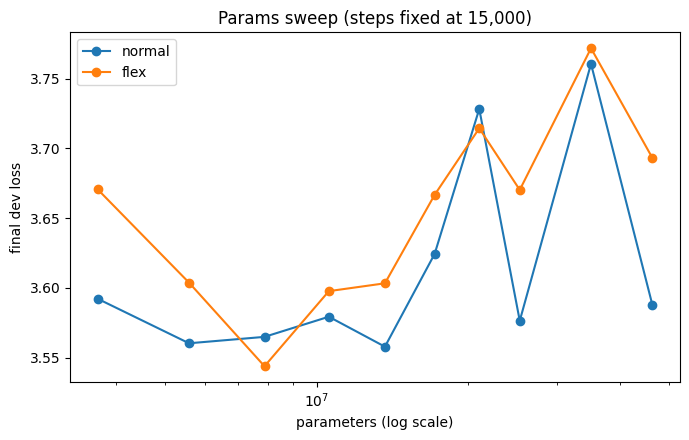

bias type        params   dev loss
normal        3,686,400      3.592
normal        5,590,784      3.560
normal        7,888,384      3.565
normal       10,579,200      3.579
normal       13,663,232      3.558
normal       17,140,480      3.624
normal       21,010,944      3.728
normal       25,274,624      3.576
normal       34,981,632      3.761
normal       46,261,504      3.588
flex          3,686,400      3.671
flex          5,590,784      3.604
flex          7,888,384      3.544
flex         10,579,200      3.598
flex         13,663,232      3.603
flex         17,140,480      3.667
flex         21,010,944      3.714
flex         25,274,624      3.670
flex         34,981,632      3.772
flex         46,261,504      3.693


In [ ]:
def sweep_rows(bias_type, sweep_name):
    rows = [r for r in results if r["bias_type"] == bias_type and r["sweep"] in ("baseline", sweep_name)]
    return sorted(rows, key=lambda r: r["params"] if sweep_name == "params" else r["steps"])

plt.figure(figsize=(7, 4.5))
for bias_type in BIAS_TYPES:
    rows = sweep_rows(bias_type, "params")
    plt.plot([r["params"] for r in rows], [r["final_dev_loss"] for r in rows], marker="o", label=bias_type)
plt.xscale("log")
plt.xlabel("parameters (log scale)")
plt.ylabel("final dev loss")
plt.title(f"Params sweep (steps fixed at {STEPS:,})")
plt.legend()
plt.tight_layout()
plt.show()

print(f"{'bias type':10s} {'params':>12s} {'dev loss':>10s}")
for bias_type in BIAS_TYPES:
    for r in sweep_rows(bias_type, "params"):
        print(f"{bias_type:10s} {r['params']:>12,d} {r['final_dev_loss']:>10.3f}")


## 5. Compare: steps sweep

Dev loss vs. training steps, log-x, one line per bias type. Watch for where
(or whether) the curves flatten out or start climbing back up -- that's the
overfitting point, which this sweep was deliberately allowed to run past.


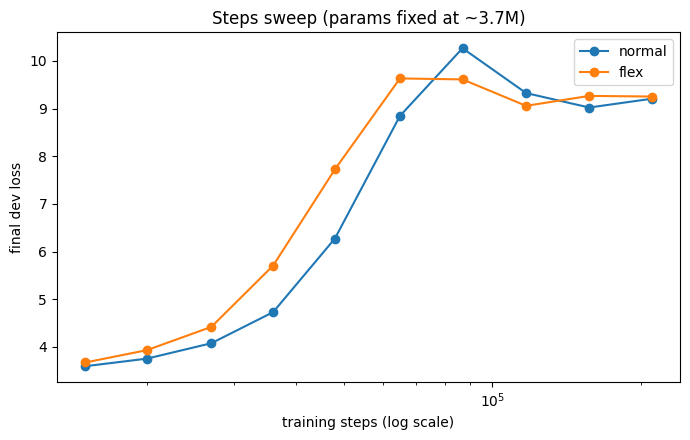

bias type       steps   dev loss
normal         15,000      3.592
normal         20,000      3.752
normal         27,000      4.075
normal         36,000      4.727
normal         48,000      6.272
normal         65,000      8.847
normal         87,000     10.267
normal        117,000      9.326
normal        157,000      9.023
normal        210,000      9.207
flex           15,000      3.671
flex           20,000      3.930
flex           27,000      4.418
flex           36,000      5.705
flex           48,000      7.723
flex           65,000      9.633
flex           87,000      9.613
flex          117,000      9.058
flex          157,000      9.266
flex          210,000      9.253


In [ ]:
baseline_params = sweep_rows(BIAS_TYPES[0], "steps")[0]["params"]

plt.figure(figsize=(7, 4.5))
for bias_type in BIAS_TYPES:
    rows = sweep_rows(bias_type, "steps")
    plt.plot([r["steps"] for r in rows], [r["final_dev_loss"] for r in rows], marker="o", label=bias_type)
plt.xscale("log")
plt.xlabel("training steps (log scale)")
plt.ylabel("final dev loss")
plt.title(f"Steps sweep (params fixed at ~{baseline_params/1e6:.1f}M)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"{'bias type':10s} {'steps':>10s} {'dev loss':>10s}")
for bias_type in BIAS_TYPES:
    for r in sweep_rows(bias_type, "steps"):
        print(f"{bias_type:10s} {r['steps']:>10,d} {r['final_dev_loss']:>10.3f}")


## 6. Sample continuations at the extremes

The smallest and largest model from each sweep, for a qualitative look at
whether "lower dev loss" actually reads as more coherent text.


In [ ]:
for bias_type in BIAS_TYPES:
    for sweep_name in ("params", "steps"):
        rows = sweep_rows(bias_type, sweep_name)
        smallest, largest = rows[0], rows[-1]
        print(f"\n=== {bias_type} / {sweep_name} sweep ===")
        print(f"--- smallest: {smallest['run_name']} ---")
        print(smallest["sample"])
        print(f"\n--- largest: {largest['run_name']} ---")
        print(largest["sample"])



=== normal / params sweep ===
--- smallest: normal-3.7M-15000steps ---
    ROMEO:
Hark, what is your eye:
And with the grief, King Richard slain's body
To banish strong right conference
That brasses and way.

HENRY BOLINGBROKE

--- largest: normal-46.3M-15000steps ---
    ROMEO:
A queen, gherdess, like you no allion?

BENVOLIO:
I praise on Rome and form and ancient right!

MENENIUS:
What was your lord; not.

HENRY BOLINGBROKE

=== normal / steps sweep ===
--- smallest: normal-3.7M-15000steps ---
    ROMEO:
Hark, what is your eye:
And with the grief, King Richard slain's body
To banish strong right conference
That brasses and way.

HENRY BOLINGBROKE

--- largest: normal-3.7M-210000steps ---
    ROMEO:
Amen, amen! but come what sorrow can,
It cannot countervail the exchange of joy
That one short minute gives me in her sight:
Do thou but close our hands

=== flex / params sweep ===
--- smallest: flex-3.7M-15000steps ---
    ROMEO:
Hark, what is not, like you no allow'd means, King Richar